In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

-- Load Data --

In [2]:
Telco_df = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
print(f"Data loaded successfully: {Telco_df.shape[0]} rows dan {Telco_df.shape[1]} columns.")
display(Telco_df.head())

Data loaded successfully: 7043 rows dan 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
Telco_df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [5]:
Telco_df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
Telco_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


-- Data Cleaning --

In [7]:
# Convert TotalCharges to numeric
Telco_df['TotalCharges'] = pd.to_numeric(Telco_df['TotalCharges'], errors='coerce')
print("Missing values :\n", Telco_df.isnull().sum())

Missing values :
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [8]:
Telco_df.dropna(subset=['TotalCharges'], inplace=True)
Telco_df.drop('customerID', axis=1, inplace=True)
print(Telco_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

-- ANALYSIS DISTRIBUTION TARGET --

C:\Users\USER\AppData\Local\Temp\ipykernel_1264\3292986474.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=Telco_df, palette='viridis')


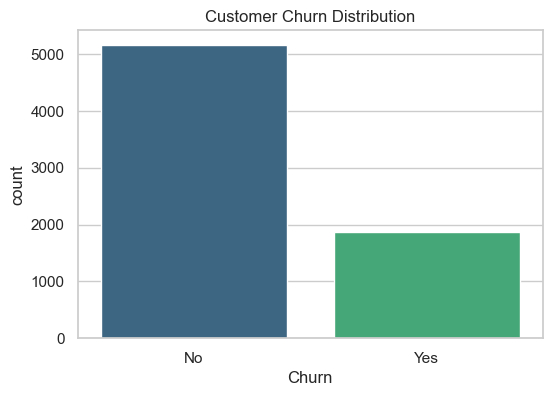

In [9]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=Telco_df, palette='viridis')
plt.title('Customer Churn Distribution')
plt.show()

In [10]:
print("--- Churn Distribution Amount ---")
print(Telco_df['Churn'].value_counts())
print("\n--- Churn Distribution Percentage ---")
print(100 * Telco_df['Churn'].value_counts() / len(Telco_df))

--- Churn Distribution Amount ---
Churn
No     5163
Yes    1869
Name: count, dtype: int64

--- Churn Distribution Percentage ---
Churn
No     73.421502
Yes    26.578498
Name: count, dtype: float64


Terjadi ketidakseimbangan data yang menunjukkan 73% pelanggan tidak churn 26% pelanggan churn.
Kita harus menggunakan teknik sampling (SMOTEENN) agar model dapat mengenali pola mikro dari pelanggan yang akan berhenti.

-- CATEGORICAL FEATURE NUMERICAL --

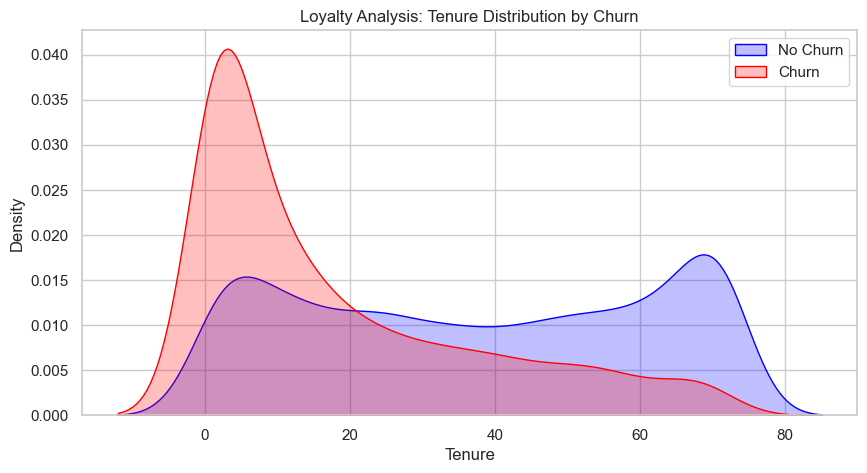

In [11]:
# Tenure Distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(Telco_df[Telco_df['Churn'] == 'No']['tenure'], label='No Churn', fill=True, color="blue")
sns.kdeplot(Telco_df[Telco_df['Churn'] == 'Yes']['tenure'], label='Churn', fill=True, color="red")
plt.title('Loyalty Analysis: Tenure Distribution by Churn')
plt.xlabel('Tenure')
plt.ylabel('Density')
plt.legend()
plt.show()

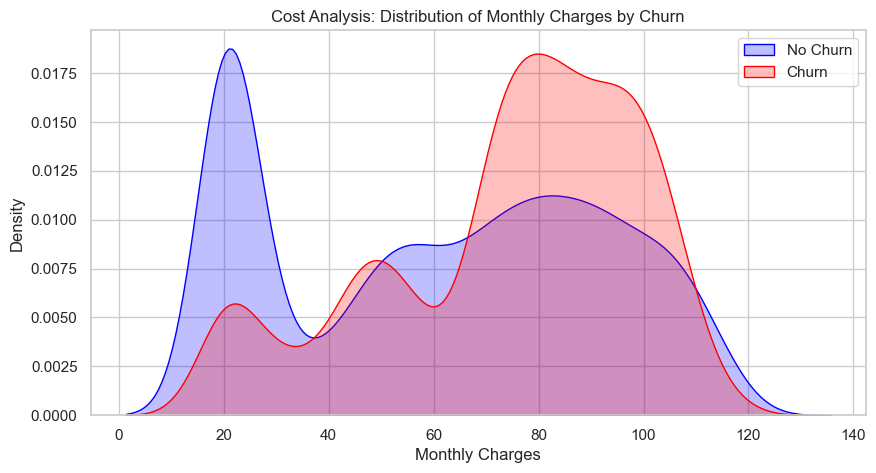

In [12]:
# Monthly Charges Distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(Telco_df[Telco_df['Churn'] == 'No']['MonthlyCharges'], label='No Churn', fill=True, color="blue")
sns.kdeplot(Telco_df[Telco_df['Churn'] == 'Yes']['MonthlyCharges'], label='Churn', fill=True, color="red")
plt.title('Cost Analysis: Distribution of Monthly Charges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.legend()
plt.show()

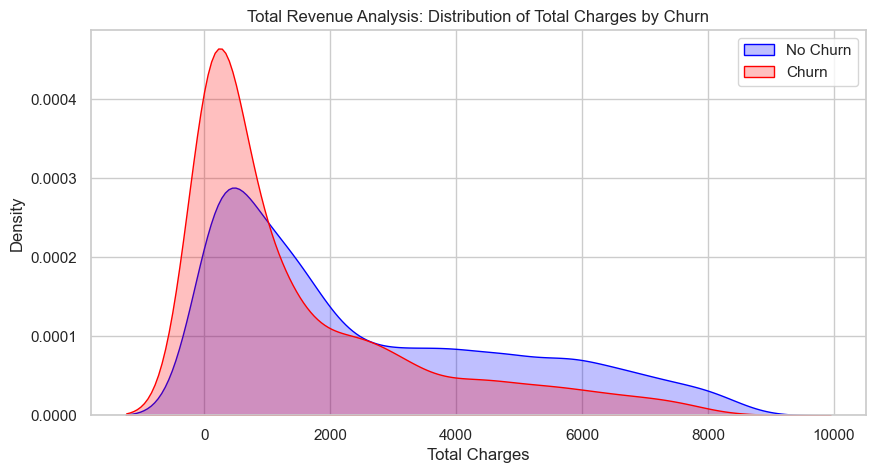

In [13]:
# 3. Total Charges Distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(Telco_df[Telco_df['Churn'] == 'No']['TotalCharges'], label='No Churn', fill=True, color="blue")
sns.kdeplot(Telco_df[Telco_df['Churn'] == 'Yes']['TotalCharges'], label='Churn', fill=True, color="red")
plt.title('Total Revenue Analysis: Distribution of Total Charges by Churn')
plt.xlabel('Total Charges')
plt.ylabel('Density')
plt.legend()
plt.show()

-- CATEGORICAL FEATURE ANALYSIS --

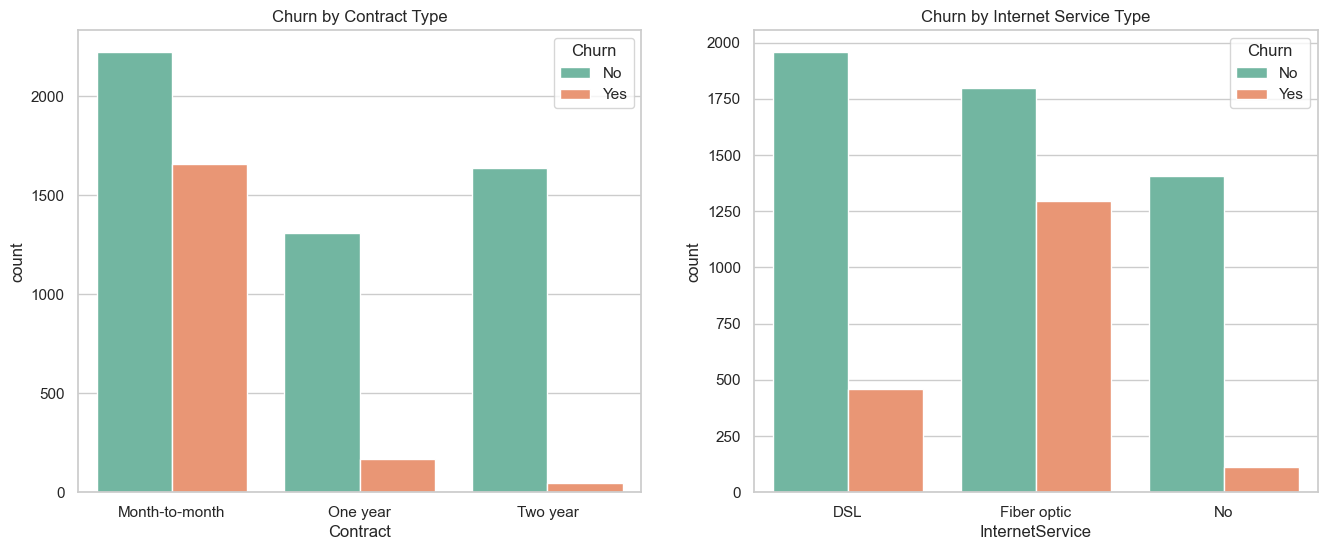

In [14]:
# Important Categorical Feature Analysis
# Looking at how internet contracts and types affect churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='Contract', hue='Churn', data=Telco_df, ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Contract Type')

sns.countplot(x='InternetService', hue='Churn', data=Telco_df, ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Internet Service Type')

plt.show()

-- HEATMAP CORELATION --

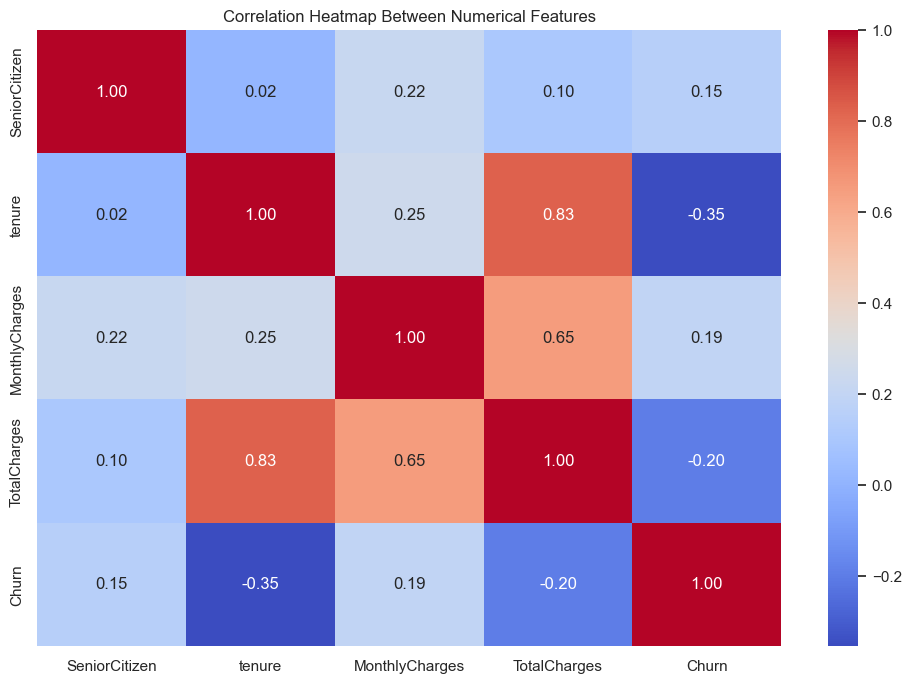

In [15]:
# Correlation Heatmap (After simple Encoding for visualization)
Telco_df_corr = Telco_df.copy()
Telco_df_corr['Churn'] = Telco_df_corr['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
plt.figure(figsize=(12, 8))
sns.heatmap(Telco_df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Between Numerical Features')
plt.show()

Conclusion:
1. Customers with a subscription period of 1-12 months are at risk of churn.
2. Customers with high bills are at higher risk of churn than those with low-cost plans.

-- SAVE THE CLEAN DATA --

In [16]:
data_model = pd.get_dummies(Telco_df)
Telco_df.to_csv('telco_churn_ready_model.csv', index=False)